# Лабораторная работа №3
## Вариант 3.2
#### Выполнили: Аверьянова Мария, Калягин Дмитрий, Кашникова Анна, Климович Анна


## Исходная задача

Рассмотрим задачу минимизации:

$$
\begin{aligned}
\text{minimize} \quad & f(x) = \sum_{i=1}^n x_i \log x_i \\
\text{subject to} \quad & Ax = b
\end{aligned}
$$

где $x \in \mathbb{R}^n$, $A \in \mathbb{R}^{p \times n}$, $b \in \mathbb{R}^p$, $p < n$.



## 1. Исследование на выпуклость

Целевая функция $f(x)$ является суммой функций вида $h(u) = u \log u$. Исследуем выпуклость этой функции на области $x_i > 0$:

$$
h''(u) = \frac{d^2}{du^2}(u \log u) = \frac{d}{du}(1 + \log u) = \frac{1}{u}
$$

Так как $\frac{1}{u} > 0$ для всех $u > 0$, функция $u \log u$ строго выпукла.
Сумма строго выпуклых функций также строго выпукла, поэтому $f(x)$ строго выпукла на области $x_i > 0$.

Ограничения $Ax = b$ задают аффинное множество, которое является выпуклым.

Поэтому исходная задача — выпуклая.



## Формулировка двойственной задачи

Запишем лагранжиан задачи:

$$
L(x, \lambda) = \sum_{i=1}^n x_i \log x_i + \lambda^T(Ax - b)
$$

Для нахождения двойственной функции $q(\lambda) = \inf_x L(x, \lambda)$ приравняем частную производную по каждому $x_i$ к нулю:

$$
\frac{\partial L}{\partial x_i} = \log x_i + 1 + a_i^T \lambda = 0
$$

Отсюда находим оптимальное $x^*$, выраженное через $\lambda$:

$$
\log x_i^*(\lambda) = -1 - a_i^T \lambda \quad \Rightarrow \quad x_i^*(\lambda) = \exp(-1 - a_i^T \lambda)
$$

Подставим $x^*(\lambda)$ обратно в лагранжиан:

$$
\begin{aligned}
q(\lambda) &= L(x^*(\lambda), \lambda) \\
&= \sum_{i=1}^n x_i^* \log x_i^* + \lambda^T A x^* - \lambda^T b \\
&= \sum_{i=1}^n x_i^* (-1 - a_i^T \lambda) + \sum_{i=1}^n x_i^* (a_i^T \lambda) - b^T \lambda \\
&= \sum_{i=1}^n (-x_i^*) - b^T \lambda \\
&= -\sum_{i=1}^n \exp(-1 - a_i^T \lambda) - b^T \lambda
\end{aligned}
$$

Таким образом, двойственная функция имеет вид:

$$
q(\lambda) = -b^T \lambda - \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

Двойственная задача заключается в максимизации этой функции:

$$
\max_{\lambda \in \mathbb{R}^p} \quad q(\lambda)
$$

Или в форме минимизации:

$$
\text{minimize} \quad b^T \lambda + \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

# 2. Генерация тестовых примеров и эталонное решение через CVXPY

In [15]:
import matplotlib.pyplot as plt
import time

import numpy as np
import cvxpy as cp
import pandas as pd

from scipy.linalg import svd
from typing import List, Dict



ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ



In [2]:
def entropy_objective(x: np.ndarray) -> float:
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))


def recover_primal_from_dual(nu: np.ndarray, A: np.ndarray) -> np.ndarray:
    return np.exp(-A.T @ nu - 1)


def generate_full_rank_matrix(p: int, n: int, rng):
    while True:
        A = rng.standard_normal((p, n))
        if np.linalg.matrix_rank(A) == p:
            return A


def nullspace_basis(A: np.ndarray, tol=1e-12) -> np.ndarray:
    U, S, Vt = svd(A, full_matrices=True)
    rank = np.sum(S > tol * S[0])
    return Vt[rank:].T

ГЕНЕРАЦИЯ ЗАДАЧИ

In [3]:
def generate_test_problem(n: int, p: int, seed: int):
    rng = np.random.default_rng(seed)

    A = generate_full_rank_matrix(p, n, rng)

    x_feas = 0.5 + np.abs(rng.standard_normal(n))
    b = A @ x_feas

    N = nullspace_basis(A)

    return {
        'A': A,
        'b': b,
        'x_feas': x_feas,
        'N': N,
        'rng': rng
    }

СТАРТОВЫЕ ТОЧКИ


In [4]:
def generate_feasible_starts(x_ref, N, num_starts, rng):
    starts = []
    n_p = N.shape[1]

    if n_p == 0:
        return [x_ref.copy() for _ in range(num_starts)]

    for _ in range(num_starts):
        z = rng.standard_normal(n_p)
        direction = N @ z

        alpha_max = np.inf
        mask = direction < 0
        if np.any(mask):
            alpha_max = np.min(x_ref[mask] / (-direction[mask])) * 0.5

        alpha = alpha_max * (0.2 + 0.6 * rng.random()) if np.isfinite(alpha_max) else 0

        x0 = x_ref + alpha * direction
        x0 = np.maximum(x0, 1e-8)

        starts.append(x0)

    return starts

CVXPY РЕШЕНИЕ

In [5]:

def solve_primal(A, b):
    n = A.shape[1]
    x = cp.Variable(n)

    objective = cp.Minimize(cp.sum(-cp.entr(x)))
    constraints = [A @ x == b, x >= 1e-9]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if x.value is None:
        raise RuntimeError("Primal solve failed")

    x_star = x.value
    f_star = entropy_objective(x_star)

    return x_star, f_star


def solve_dual(A, b):
    p = A.shape[0]
    nu = cp.Variable(p)

    phi_expr = b @ nu + cp.sum(cp.exp(-1 - A.T @ nu))

    prob = cp.Problem(cp.Minimize(phi_expr))
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if nu.value is None:
        raise RuntimeError("Dual solve failed")

    nu_star = nu.value

    # минимум -q
    phi_star = prob.value
    # максимум q
    q_star = -phi_star

    return nu_star, q_star, phi_star

In [6]:
def build_dataset():
    n_values = range(10, 101, 10)
    num_instances = 5
    num_starts = 5

    problems: List[Dict] = []

    for n in n_values:
        p = n // 2

        print(f"\n=== n = {n}, p = {p} ===")

        for inst_id in range(num_instances):
            seed = 1000 * n + inst_id

            prob = generate_test_problem(n, p, seed)
            A, b, N, rng = prob['A'], prob['b'], prob['N'], prob['rng']

            # CVXPY решения
            x_star, f_star = solve_primal(A, b)
            nu_star, q_star, phi_star = solve_dual(A, b)

            x_dual = recover_primal_from_dual(nu_star, A)
            gap = abs(f_star - q_star)
            starts = generate_feasible_starts(prob["x_feas"], N, num_starts, rng)
            dual_starts = [rng.standard_normal(p) for _ in range(num_starts)]

            problems.append({
                'n': n,
                'p': p,
                'A': A,
                'b': b,
                'N': N,
                'x_feas': prob['x_feas'],
                'x_star': x_star,
                'f_star': f_star,
                'nu_star': nu_star,
                'q_star': q_star,
                'phi_star': phi_star,
                'starts': starts,
                'dual_starts': dual_starts,
            })

    return problems

In [7]:
problems = build_dataset()

import pickle
with open("entropy_problems.pkl", "wb") as f:
    pickle.dump(problems, f)

print("\nDataset saved to entropy_problems.pkl")


=== n = 10, p = 5 ===

=== n = 20, p = 10 ===

=== n = 30, p = 15 ===

=== n = 40, p = 20 ===

=== n = 50, p = 25 ===

=== n = 60, p = 30 ===

=== n = 70, p = 35 ===

=== n = 80, p = 40 ===

=== n = 90, p = 45 ===

=== n = 100, p = 50 ===

Dataset saved to entropy_problems.pkl


# 3. Для прямой и двойственной задач, каждого $n \in \{10, 20, \ldots, 100\}$, каждого тестового примера и каждой из 5 начальных точек реализуйте следующие методы для точности $\varepsilon = 0.01^2$:

   a) демпфированный метод Ньютона для задачи с линейными ограничениями (Boyd, §10.2, p. 525); сопоставьте результаты для прямой и двойственной задач;
   
   b) комбинированную схему, в которой на начальном этапе применяется градиентный спуск, а затем осуществляется переход к методу Ньютона;
   
   c) методы Broyden и BFGS, использующие следующие формулы обновления аппроксимации обратного гессиана:

   $$H^{\text{new}} = H + \frac{(s - Hy)s^T H}{s^T H y}$$

   для метода Broyden и

   $$H^{\text{new}} = \left(I - \frac{sy^T}{y^T s}\right) H \left(I - \frac{ys^T}{y^T s}\right) + \frac{ss^T}{y^T s}$$

   для метода BFGS, где

   $$s = x^{k+1} - x^k, \qquad y = \nabla f(x^{k+1}) - \nabla f(x^k).$$


---

$^2$Под точностью понимается выполнение неравенства $|f(x^k) - f^*| \le \varepsilon$, где $f^*$ — оптимальное значение функции.

In [8]:
EPS = 1e-4
MAX_ITER = 100

def newton_primal(problem, x0):
    A = problem['A']
    b = problem['b']
    f_star = problem['f_star']

    x = x0.copy()
    history = []

    # Параметры для line search
    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        grad = np.log(x) + 1
        H = np.diag(1 / x)
        f_val = np.sum(x * np.log(x))
        history.append({
            "iter": k,
            "obj": f_val,
            "error": abs(f_val - f_star)
        })

        # 1. Проверка критерия остановки
        if abs(f_val - f_star) <= EPS:
            return x, history, k

        # 2. Решение системы KKT
        KKT = np.block([
            [H, A.T],
            [A, np.zeros((A.shape[0], A.shape[0]))]
        ])
        rhs = -np.concatenate([grad, A @ x - b])

        try:
            sol = np.linalg.solve(KKT, rhs)
            dx = sol[:len(x)]
        except np.linalg.LinAlgError:
            print("KKT matrix singular")
            break

        # 3. Демпфирование (Backtracking line search)
        t = 1.0
        while True:
            x_new = x + t * dx
            if np.any(x_new <= 0):
                t *= beta
            else:
                f_new = np.sum(x_new * np.log(x_new))
                if f_new <= f_val + alpha * t * (grad @ dx):
                    break

                t *= beta

            if t < 1e-12:
                print("Line search failed")
                return x, history, k

        x = x_new

    return x, history, MAX_ITER

ДВОЙСТВЕННАЯ ЗАДАЧА: NEWTON

In [9]:
def dual_phi(nu, A, b):
    """
    phi(nu) = -q(nu)
    Минимизируемая двойственная функция.
    """
    return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


def dual_phi_grad(nu, A, b):
    """
    Градиент phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return b - A @ exp_term


def dual_phi_hess(nu, A):
    """
    Гессиан phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return A @ np.diag(exp_term) @ A.T


def newton_dual(problem, nu0):
    A = problem['A']
    b = problem['b']
    phi_star = problem['phi_star']

    nu = nu0.copy()
    history = []

    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        grad = dual_phi_grad(nu, A, b)
        H = dual_phi_hess(nu, A)

        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error
        })

        if error <= EPS:
            return nu, history, k

        try:
            dnu = -np.linalg.solve(H, grad)
        except np.linalg.LinAlgError:
            print("Dual Hessian singular")
            break

        t = 1.0
        while True:
            nu_new = nu + t * dnu
            phi_new = dual_phi(nu_new, A, b)

            if phi_new <= phi_val + alpha * t * (grad @ dnu):
                break

            t *= beta
            if t < 1e-12:
                print("Line search failed")
                return nu, history, k

        nu = nu_new

    return nu, history, MAX_ITER

In [10]:
def hybrid_method(problem, x0):
    raise NotImplementedError("Hybrid method not implemented")


def broyden_method(problem, x0):
    raise NotImplementedError("Broyden not implemented")


def bfgs_method(problem, x0):
    raise NotImplementedError("BFGS not implemented")

СРАВНЕНИЕ МЕТОДОВ

In [11]:
def run_experiments(problems):
    results = []

    for prob_id, problem in enumerate(problems):
        A = problem['A']
        p = A.shape[0]

        for start_id, x0 in enumerate(problem['starts']):

            # старт для двойственной
            nu0 = problem['dual_starts'][start_id]

            # PRIMAL
            t0 = time.time()
            x_sol, hist_p, it_p = newton_primal(problem, x0)
            time_p = time.time() - t0

            # DUAL
            t0 = time.time()
            nu_sol, hist_d, it_d = newton_dual(problem, nu0)
            time_d = time.time() - t0

            results.append({
                'problem_id': prob_id,
                'n': problem['n'],
                'start_id': start_id,

                'primal_iters': it_p,
                'dual_iters': it_d,

                'primal_time': time_p,
                'dual_time': time_d,

                'primal_final_error': hist_p[-1]["error"],
                'dual_final_error': hist_d[-1]["error"],

                'primal_success': hist_p[-1]["error"] <= EPS,
                'dual_success': hist_d[-1]["error"] <= EPS,
            })

            print(f"n={problem['n']} | start={start_id} | "
                  f"primal it={it_p}, dual it={it_d} | primal time={time_p}, dual_time={time_d}")

    return results

In [12]:
results = run_experiments(problems)

n=10 | start=0 | primal it=4, dual it=7 | primal time=0.0025696754455566406, dual_time=0.005990266799926758
n=10 | start=1 | primal it=4, dual it=7 | primal time=0.00028443336486816406, dual_time=0.0001430511474609375
n=10 | start=2 | primal it=4, dual it=5 | primal time=0.00011968612670898438, dual_time=0.00010275840759277344
n=10 | start=3 | primal it=4, dual it=4 | primal time=0.00011348724365234375, dual_time=8.869171142578125e-05
n=10 | start=4 | primal it=4, dual it=6 | primal time=0.0001125335693359375, dual_time=0.00012350082397460938
n=10 | start=0 | primal it=3, dual it=4 | primal time=8.869171142578125e-05, dual_time=7.891654968261719e-05
n=10 | start=1 | primal it=3, dual it=4 | primal time=8.678436279296875e-05, dual_time=8.320808410644531e-05
n=10 | start=2 | primal it=3, dual it=7 | primal time=8.726119995117188e-05, dual_time=0.0001571178436279297
n=10 | start=3 | primal it=3, dual it=4 | primal time=9.918212890625e-05, dual_time=0.00013184547424316406
n=10 | start=4 | 

In [13]:
df = pd.DataFrame(results)

summary = df.groupby("n").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
    "primal_success": "mean",
    "dual_success": "mean"
}).reset_index()

summary

,n,primal_iters,dual_iters,primal_time,dual_time,primal_final_error,dual_final_error,primal_success,dual_success
0,10,3.24,4.96,0.000204,0.000362,0.000007,0.000013,1.0,1.0
1,20,3.60,7.68,0.000251,0.000340,0.000014,0.000012,1.0,1.0
2,30,3.60,9.00,0.000166,0.000213,0.000010,0.000012,1.0,1.0
3,40,4.60,10.52,0.000229,0.000263,0.000017,0.000012,1.0,1.0
4,50,4.52,12.24,0.000262,0.000352,0.000019,0.000014,1.0,1.0
5,60,4.48,15.04,0.000305,0.000505,0.000014,0.000020,1.0,1.0
6,70,4.44,15.48,0.000378,0.000689,0.000033,0.000010,1.0,1.0
7,80,4.56,17.44,0.000544,0.000841,0.000020,0.000011,1.0,1.0
8,90,4.72,18.40,0.000623,0.000991,0.000027,0.000006,1.0,1.0
9,100,4.56,20.48,0.000714,0.001391,0.000009,0.000017,1.0,1.0


<Axes: xlabel='n'>

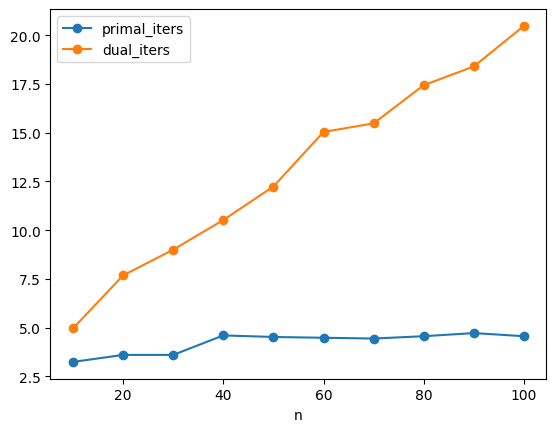

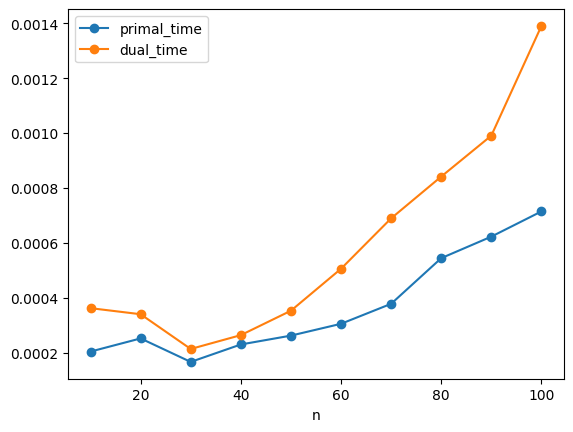

In [14]:
summary.plot(x="n", y=["primal_iters", "dual_iters"], marker="o")
summary.plot(x="n", y=["primal_time", "dual_time"], marker="o")

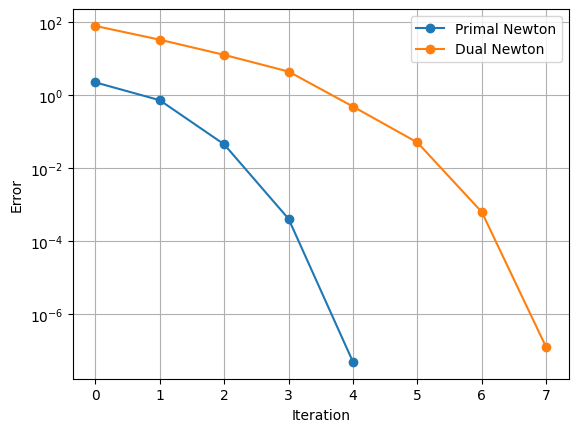

In [17]:
problem = problems[0]

x0 = problem["starts"][0]
nu0 = problem["dual_starts"][0]

x_sol, hist_p, it_p = newton_primal(problem, x0)
nu_sol, hist_d, it_d = newton_dual(problem, nu0)

plt.semilogy([h["iter"] for h in hist_p], [h["error"] for h in hist_p], label="Primal Newton", marker="o")
plt.semilogy([h["iter"] for h in hist_d], [h["error"] for h in hist_d], label="Dual Newton", marker="o")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()